# 15_正则化方法-弹性网络正则化

## Notebook 使用说明

建议先阅读理论，再从上到下运行全部单元；使用 Python 3.11–3.13 内核。数据与辅助模块均来自本文件夹，安装依赖后无需联网获取案例数据。

本篇数据：`dataset/BostonHousing.csv`。

转写调整：

- ElasticNet 搜索去掉 l1_ratio=0 的退化边界，增加迭代上限并缩小用于热力图的候选网格。
- 修复或适配代码；原讲解性输出保留为 Markdown，Python 单元按顺序执行。

原文参考图及静态数值仅用于对照；重跑后的代码输出为本次实验结果。依赖版本与验证记录见根目录 `README.md` 和 `reports/`。

In [1]:
# 从当前目录向上寻找本套 Notebook 的根目录，移动整个文件夹后仍可运行。
from pathlib import Path
import os, sys, tempfile, random
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "notebook_support.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("请从这套 Notebook 文件夹内启动 Jupyter，并保留 notebook_support.py。")
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib"))
from notebook_support import DATA_DIR, load_local_housing, load_local_boston, load_local_mnist, load_creditcard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
random.seed(42)
np.random.seed(42)
# 按实际安装的字体选择，兼容 macOS / Windows / Linux。
_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei", "SimHei", "Noto Sans CJK SC"]
             if f in _available_fonts] + ["DejaVu Sans"]
plt.rcParams.update({"font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
                     "figure.dpi": 90, "figure.max_open_warning": 30})
%matplotlib inline


前面，和大家分享了Lasso回归和Ridge回归之后。

这里想和大家一起讨论的是：弹性网络正则化！\~\~

首先，举个例子，大家有一个大致的印象，知道它是干啥的？

假设你在训练一个预测房价的模型，有很多特征（如房子的面积、卧室数量、位置等）。有些特征可能对预测房价并不重要，甚至会增加噪音。如果你使用弹性网络正则化，模型会自动选择重要的特征，并抑制不重要特征的影响，从而提高预测的准确性和模型的稳定性。

**弹性网络正则化 主要是为了防止模型过拟合并提高模型的泛化能力。**

那其次，再来谈谈正则化：

正则化 用来防止模型过拟合。过拟合是指模型在训练数据上表现很好，但在新数据上表现不佳。正则化通过添加额外的信息（通常是一些约束或惩罚）来让模型在训练时不过于“记住”训练数据的细节，而是学到更普遍的规律。

那么，弹性网络正则化是什么？

弹性网络正则化是将两种常见的正则化方法：L1正则化（Lasso）和L2正则化（Ridge）结合起来的一种方法。

- **L1正则化（Lasso）**：通过增加一个参数，使得一些不重要的特征的系数变为零，这样可以进行特征选择。
- **L2正则化（Ridge）**：通过增加一个参数，使得所有特征的系数变得更小，这样可以减少模型的复杂度。

弹性网络正则化结合了这两者的优点，可以同时进行特征选择和防止模型过于复杂。

所以，这个时候就知道为什么要选择弹性网络正则化了！

1. **特征选择**：L1正则化会将不重要的特征的系数缩减为零，从而自动进行特征选择。
2. **稳定性**：L2正则化会使得所有特征的系数变小，防止某些特征的系数过大，从而增加模型的稳定性。
3. **处理多重共线性**：当多个特征之间高度相关时，L1和L2单独使用可能效果不好，而弹性网络可以更好地处理这种情况。

**也就是说，弹性网络正则化是结合了L1和L2正则化优点的一种方法，可以有效防止模型过拟合，并提高模型的泛化能力。**

## 理论基础

弹性网络正则化 结合了L1正则化（Lasso）和L2正则化（Ridge）的优点，通过引入两个正则化参数来控制L1和L2正则化的比例，进而实现特征选择和防止模型复杂度过高。

#### 1. 线性回归模型

首先考虑一个线性回归模型：


$$
y = X\beta + \epsilon
$$


其中：

- $y$是响应变量向量（维度为 $n$）。
- $X$是特征矩阵（维度为 $n \times p$）。
- $\beta$是待估计的回归系数向量（维度为 $p$）。
- $\epsilon$是误差项（维度为 $n$）。

#### 2. 损失函数

线性回归模型的普通最小二乘（OLS）损失函数为：


$$
L(\beta) = \frac{1}{2} \| y - X\beta \|_2^2 = \frac{1}{2} (y - X\beta)^T (y - X\beta)
$$


#### 3. L1 正则化（Lasso）

Lasso的目标函数是将L1正则化项加入到损失函数中：


$$
L_{\text{Lasso}}(\beta) = \frac{1}{2} \| y - X\beta \|_2^2 + \lambda_1 \| \beta \|_1
$$


其中 $\| \beta \|_1 = \sum_{j=1}^{p} | \beta_j |$是L1范数，$\lambda_1$ 是正则化参数。

#### 4. L2 正则化（Ridge）

Ridge的目标函数是将L2正则化项加入到损失函数中：


$$
L_{\text{Ridge}}(\beta) = \frac{1}{2} \| y - X\beta \|_2^2 + \lambda_2 \| \beta \|_2^2
$$


其中 $\| \beta \|_2^2 = \sum_{j=1}^{p} \beta_j^2$是L2范数的平方，$\lambda_2$ 是正则化参数。

#### 5. 弹性网络正则化（Elastic Net）

弹性网络正则化结合了Lasso和Ridge正则化，通过引入两个正则化参数来控制L1和L2正则化的比例，其目标函数为：


$$
L_{\text{ElasticNet}}(\beta) = \frac{1}{2} \| y - X\beta \|_2^2 + \lambda_1 \| \beta \|_1 + \lambda_2 \| \beta \|_2^2
$$


为了简化问题，一般会引入一个混合参数 $\alpha$ 和一个总正则化参数 $\lambda$，其中 $\alpha \in [0, 1]$，$\lambda > 0$。

目标函数变为：


$$
L_{\text{ElasticNet}}(\beta) = \frac{1}{2} \| y - X\beta \|_2^2 + \lambda \left( \alpha \| \beta \|_1 + \frac{1 - \alpha}{2} \| \beta \|_2^2 \right)
$$


其中：

- $\lambda$ 是控制整体正则化强度的参数。
- $\alpha$ 控制L1和L2正则化的比例，$\alpha = 1$时为Lasso，$\alpha = 0$时为Ridge。

### 弹性网络正则化过程推导

为了更清楚地理解弹性网络的优化过程，我们对目标函数求导。

考虑无偏估计的情况，即对 $\beta$ 求导并设置导数为零。

目标函数：


$$
L_{\text{ElasticNet}}(\beta) = \frac{1}{2} \| y - X\beta \|_2^2 + \lambda \left( \alpha \| \beta \|_1 + \frac{1 - \alpha}{2} \| \beta \|_2^2 \right)
$$


将其展开：


$$
L_{\text{ElasticNet}}(\beta) = \frac{1}{2} (y - X\beta)^T (y - X\beta) + \lambda \alpha \sum_{j=1}^{p} | \beta_j | + \lambda \frac{1 - \alpha}{2} \sum_{j=1}^{p} \beta_j^2
$$


对 $\beta$ 求导：


$$
\frac{\partial L_{\text{ElasticNet}}(\beta)}{\partial \beta} = -X^T(y - X\beta) + \lambda \alpha \text{sign}(\beta) + \lambda (1 - \alpha) \beta
$$


其中 $\text{sign}(\beta)$ 是符号函数，表示 $\beta$ 的符号（正、负、零）。

令导数为零，得到优化条件：$-X^T(y - X\beta) + \lambda \alpha \text{sign}(\beta) + \lambda (1 - \alpha) \beta = 0$

这个方程在实际中通常通过迭代优化算法（如坐标下降法）来求解。

### 整体算法流程

1. **数据准备**：准备特征矩阵 $X$和响应变量 $y$。
2. **参数初始化**：选择混合参数 $\alpha$ 和总正则化参数 $\lambda$，初始化回归系数 $\beta$。
3. **迭代优化**：

   - **坐标下降法**：针对每一个回归系数 $\beta_j$，固定其他系数，更新 $\beta_j$：  
   $\beta_j \leftarrow \text{argmin}_{\beta_j} \left( \frac{1}{2} \| y - X\beta \|_2^2 + \lambda \left( \alpha | \beta_j | + \frac{1 - \alpha}{2} \beta_j^2 \right) \right)$
   - **收敛判断**：检查更新前后回归系数的变化，若变化小于预设阈值，则认为算法收敛。
4. **模型评估**：使用交叉验证等方法评估模型性能，根据需要调整 $\alpha$ 和 $\lambda$ 参数。
5. **模型应用**：使用优化后的回归系数 $\beta$ 进行预测。

弹性网络正则化，结合L1和L2正则化的优点，可以同时进行特征选择和防止模型过拟合。其目标函数通过引入两个正则化参数来控制L1和L2正则化的比例，并通过迭代优化算法求解。

## 完整案例

我们来举例一个弹性网络正则化的应用、分析和优化。这次我们选择Kaggle上的房价预测数据集（House Prices: Advanced Regression Techniques），这个数据集包含许多特征，并且任务是预测房屋价格。

#### 1. 数据集介绍

该数据集包含79个特征，如房屋的面积、建造年份、位置、装修质量等，目标是预测房屋的最终售价。

数据集，在公众号「深夜努力写Python」，后台回复『数据集』即可获取\~

#### 2. 实验步骤

1. 数据加载和预处理
2. 特征工程
3. 弹性网络模型训练
4. 超参数调优
5. 模型评估和可视化
6. 算法优化与讨论

#### 3. 实验代码

**导入必要的库**

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import warnings

**数据加载和预处理**

In [3]:
# 数据加载
train_df = pd.read_csv(DATA_DIR / 'BostonHousing.csv')

# 目标变量和特征
X = train_df.drop('medv', axis=1)
y = train_df['medv']

# 数据分割
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 特征工程
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X.select_dtypes(include=['object']).columns

# 数值特征标准化，分类特征独热编码
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(), categorical_features)
    ])

# 建立弹性网络模型的pipeline
elastic_net = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', ElasticNet(max_iter=20000))
])

**弹性网络模型训练和超参数调优**

In [4]:
# 超参数调优
param_grid = {
    'regressor__alpha': np.logspace(-4, 0, 12),
    'regressor__l1_ratio': np.linspace(0.1, 1, 4)
}

grid_search = GridSearchCV(elastic_net, param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=1, error_score='raise')
grid_search.fit(X_train, y_train)

# 最优模型
best_model = grid_search.best_estimator_
y_pred_train = best_model.predict(X_train)
y_pred_test = best_model.predict(X_test)

# 模型评估
mse_train = mean_squared_error(y_train, y_pred_train)
mse_test = mean_squared_error(y_test, y_pred_test)
r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred_test)

print(f'Best parameters: {grid_search.best_params_}')
print(f'Training MSE: {mse_train}')
print(f'Test MSE: {mse_test}')
print(f'Training R^2: {r2_train}')
print(f'Test R^2: {r2_test}')

Best parameters: {'regressor__alpha': np.float64(0.006579332246575682), 'regressor__l1_ratio': np.float64(0.1)}
Training MSE: 21.649376156779912
Test MSE: 24.345885282241333
Training R^2: 0.7507939691368846
Test R^2: 0.6680126916537751


**可视化分析**

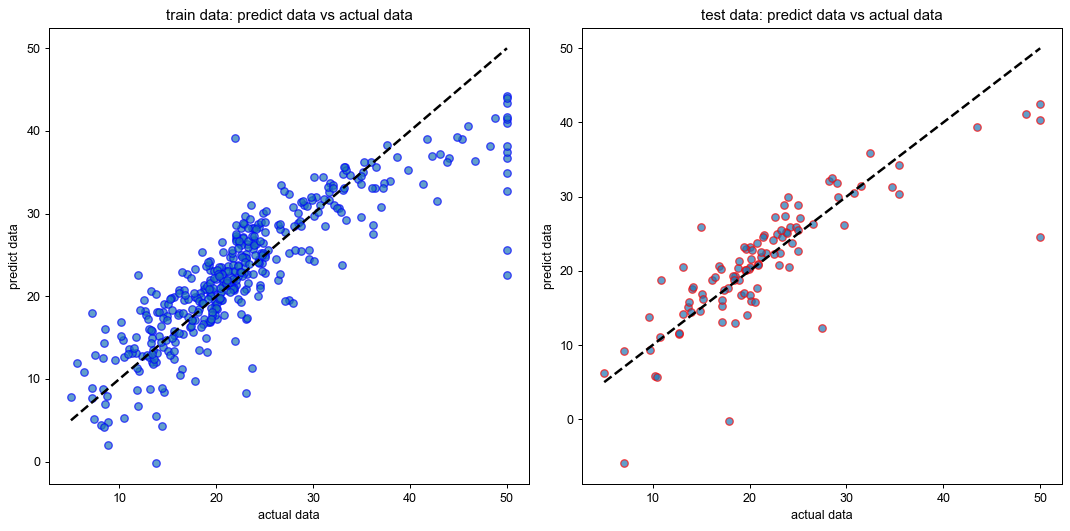

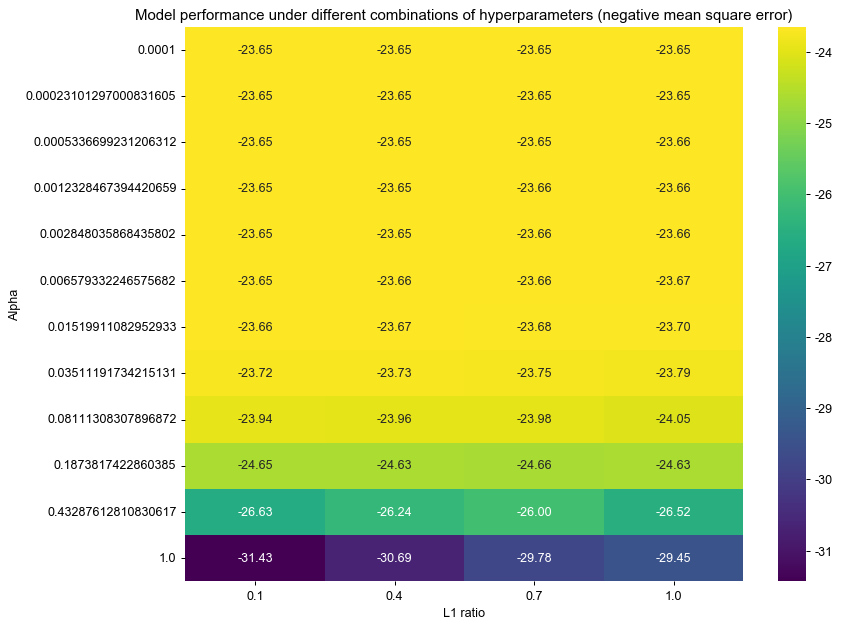

In [5]:
# 可视化预测结果
plt.figure(figsize=(12, 6))

# 训练集预测值 vs 真实值
plt.subplot(1, 2, 1)
plt.scatter(y_train, y_pred_train, alpha=0.7, edgecolors='b')
plt.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'k--', lw=2)
plt.xlabel('actual data')
plt.ylabel('predict data')
plt.title('train data: predict data vs actual data')

# 测试集预测值 vs 真实值
plt.subplot(1, 2, 2)
plt.scatter(y_test, y_pred_test, alpha=0.7, edgecolors='r')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.xlabel('actual data')
plt.ylabel('predict data')
plt.title('test data: predict data vs actual data')

plt.tight_layout()
plt.show()

# 参数效果分析
results = pd.DataFrame(grid_search.cv_results_)
scores_matrix = results.pivot(index='param_regressor__alpha', columns='param_regressor__l1_ratio', values='mean_test_score')

plt.figure(figsize=(10, 8))
sns.heatmap(scores_matrix, annot=True, fmt=".2f", cmap='viridis')
plt.title('Model performance under different combinations of hyperparameters (negative mean square error)')
plt.xlabel('L1 ratio')
plt.ylabel('Alpha')
plt.show()

![原文参考图，当前结果见代码输出](attachments/img_001.png)

![原文参考图，当前结果见代码输出](attachments/img_002.png)

过完整体代码后，我们可以直观地看到弹性网络模型在训练集和测试集上的表现，以及不同超参数组合对模型性能的影响。

## 模型分析

#### 弹性网络正则化模型的优缺点

**优点**：

1. **特征选择**：弹性网络正则化包含L1正则化（Lasso）的成分，能够将一些不重要的特征系数缩减为零，实现特征选择，简化模型。
2. **处理多重共线性**：相比单纯的Lasso或Ridge，弹性网络在处理多重共线性（特征之间高度相关）时表现更好。L2正则化成分可以分散权重，避免某些特征权重过大。
3. **稳定性**：由于L2正则化成分，模型更加稳定，防止回归系数过大，从而减小过拟合风险。
4. **灵活性**：通过调节混合参数$\alpha$，可以在L1和L2正则化之间进行权衡，从而灵活适应不同数据集和任务需求。

**缺点**：

1. **计算复杂度**：相比单独使用Lasso或Ridge，弹性网络的计算复杂度更高，尤其是在高维数据和大规模数据集上，计算开销较大。
2. **参数选择复杂**：需要同时调节两个正则化参数（$\alpha$ 和 $\lambda$），参数调优过程较复杂且耗时。
3. **可能的过拟合**：尽管弹性网络结合了L1和L2的优点，但在特征数远大于样本数的情况下，仍然存在过拟合风险。

与相似算法的对比

| **对比项** | **Lasso（L1正则化）** | **Ridge（L2正则化）** | **弹性网络（Elastic Net）** |
|-|-|-|-|
| **正则化方式** | 使用 $L1$ 范数（系数的绝对值和） | 使用 $L2$ 范数（系数的平方和） | 结合了 $L1$ 和 $L2$ 范数（系数的绝对值和与平方和） |
| **特征选择** | 能进行特征选择，能够将一些特征系数缩减为零 | 无法进行特征选择，所有特征都会包含在模型中 | 能够进行特征选择，并处理多重共线性问题 |
| **适用场景** | 适用于高维数据，特征较少且独立的情况 | 适用于处理特征相关性较高的情况，尤其是多重共线性问题 | 适用于特征较多且存在多重共线性的情况，结合了Lasso和Ridge的优点 |
| **优点** | - 能进行特征选择  <br/>- 产生稀疏模型，适用于高维数据集  <br/>- 模型简洁，易于解释 | - 防止过拟合，均匀分配权重  <br/>- 适用于多重共线性  <br/>- 模型稳定 | - 结合Lasso和Ridge的优点  <br/>- 既能进行特征选择又能处理共线性问题 |
| **缺点** | - 对特征高度相关的数据选择不稳定  <br/>- 可能随机选择其中一个特征  <br/>- 无法处理多重共线性 | - 不能进行特征选择  <br/>- 模型较为复杂，可能不简洁 | - 计算复杂度较高  <br/>- 参数调优过程复杂 |
| **模型稀疏性** | 由于$L1$正则化，模型会变得更加稀疏 | 不会产生稀疏模型，所有特征都会被包含 | 稀疏性较低，但在Lasso和Ridge之间平衡 |
| **计算复杂度** | 计算复杂度较低 | 计算复杂度较低 | 计算复杂度较高 |
| **调参** | 只需调节一个正则化参数（$\lambda$） | 只需调节一个正则化参数（$\lambda$） | 需要调节两个正则化参数（$\lambda_1$ 和 $\lambda_2$） |

#### 适用场景

**弹性网络的优选场景**

1. **特征数量多且存在多重共线性**：当特征数量多且存在多重共线性时，弹性网络能够有效地进行特征选择和处理共线性。
2. **需要特征选择**：当需要进行特征选择以降低模型复杂度时，弹性网络是一个好的选择。
3. **不同特征间差异较大**：当不同特征的重要性差异较大时，弹性网络能够通过正则化控制权重，使模型更平衡。

**考虑其他算法的场景**

1. **计算资源有限**：如果计算资源有限，可以考虑使用Lasso或Ridge，因为它们的计算复杂度较低。
2. **数据维度较低且无共线性**：当数据维度较低且不存在共线性时，Lasso或Ridge可能更适合。Lasso在这种情况下可以简化模型，而Ridge可以稳定回归系数。
3. **仅需处理多重共线性**：如果只需要处理多重共线性而不关心特征选择，Ridge回归可能是更简单的选择。

## 最后

通过对弹性网络正则化模型的优缺点分析，以及与Lasso和Ridge的对比，我们可以更好地理解在什么情况下选择弹性网络。在特征数量多、存在多重共线性并且需要特征选择时，弹性网络是优选；

而在计算资源有限、数据维度较低或仅需处理共线性时，Lasso或Ridge可能是更好的选择。